# Final network exploration

In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import islice
from collections import Counter, defaultdict
from networkx.algorithms.community import modularity


In [4]:
def input_file_path(date):
    return f"../storage/network/{date}/subreddits_network.graphml"

graphs = {}
for date in ["2020-12", "2021-12", "2022-12", "2023-12", "2024-12"]:
    graphs[date] = nx.read_graphml(input_file_path(date))

In [5]:
report = {}

for date, G in graphs.items():
    community_sizes = Counter(
        attrs["community"]
        for _, attrs in G.nodes(data=True)
        if "community" in attrs
    )
    
    communities = defaultdict(set)

    for node, attrs in G.nodes(data=True):
        communities[attrs["community"]].add(node)

    Q = modularity(G, communities.values())
    
    degrees = dict(G.degree())

    report[date] = {
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "density": nx.density(G),
        "number_communities": len(community_sizes),
        "modularity": Q,
        "max_degree": max(degrees.values()),
        "avg_degree": sum(degrees.values()) / len(degrees),
        "avg_clustering": nx.average_clustering(G)
    }
    
    print(f"Date {date}:")
    print(f"Number of nodes: {report[date]["nodes"]}")
    print(f"Number of edges: {report[date]["edges"]}")
    print(f"Density: {report[date]["density"]:.6f}")
    print(f"Number of communities: {report[date]["number_communities"]}")
    print(f"Modularity: {Q:.4f}")
    print("Max degree:", report[date]["max_degree"])
    print("Average degree:", report[date]["avg_degree"])
    print("Average clustering:", report[date]["avg_clustering"])

    print("---")

Date 2020-12:
Number of nodes: 2224
Number of edges: 4511
Density: 0.001825
Number of communities: 162
Modularity: 0.5899
Max degree: 830
Average degree: 4.056654676258993
Average clustering: 0.27069117308012663
---
Date 2021-12:
Number of nodes: 2573
Number of edges: 5282
Density: 0.001596
Number of communities: 195
Modularity: 0.5964
Max degree: 1027
Average degree: 4.105713175281772
Average clustering: 0.2652509978660654
---
Date 2022-12:
Number of nodes: 2761
Number of edges: 5266
Density: 0.001382
Number of communities: 214
Modularity: 0.6470
Max degree: 932
Average degree: 3.814559942049982
Average clustering: 0.2465795280736448
---
Date 2023-12:
Number of nodes: 2939
Number of edges: 5096
Density: 0.001180
Number of communities: 180
Modularity: 0.7461
Max degree: 713
Average degree: 3.4678462061925823
Average clustering: 0.24705793387898403
---
Date 2024-12:
Number of nodes: 3333
Number of edges: 5797
Density: 0.001044
Number of communities: 140
Modularity: 0.7997
Max degree: 46

In [5]:
# Convert the report dictionary to a pandas DataFrame
df = pd.DataFrame.from_dict(report, orient='index')

# Optional: Sort by date if the keys are not already ordered
df = df.sort_index()

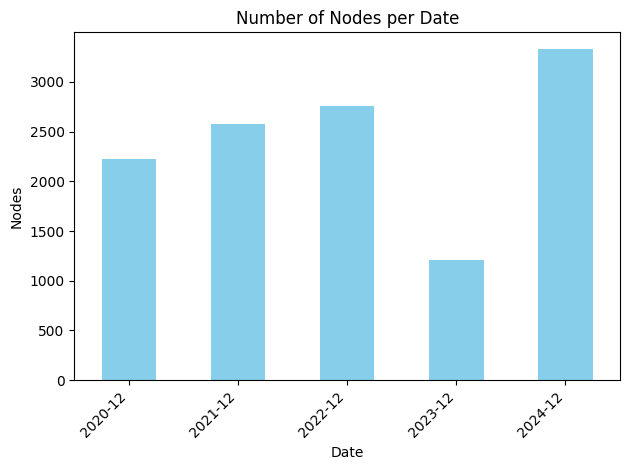

In [7]:
ax = df['nodes'].plot(kind='bar', color='skyblue')
ax.set_title('Number of Nodes per Date')
ax.set_xlabel('Date')
ax.set_ylabel('Nodes')
ax.set_xticklabels(df.index, rotation=45, ha='right')
plt.tight_layout()

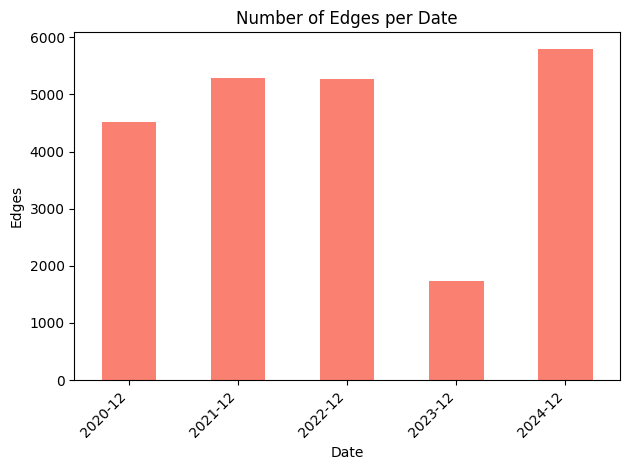

In [8]:
ax = df['edges'].plot(kind='bar', color='salmon')
ax.set_title('Number of Edges per Date')
ax.set_xlabel('Date')
ax.set_ylabel('Edges')
ax.set_xticklabels(df.index, rotation=45, ha='right')
plt.tight_layout()

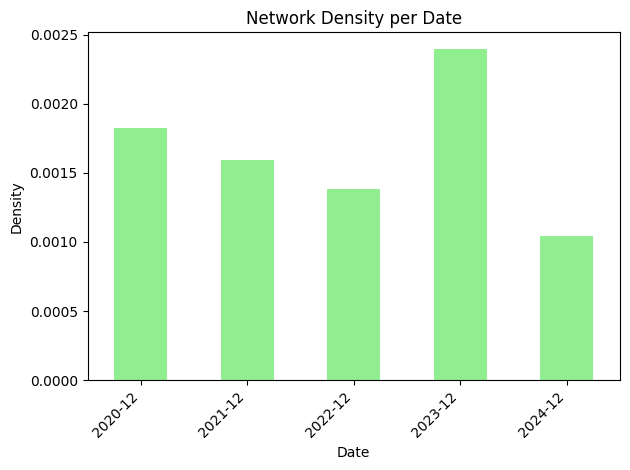

In [9]:
ax = df['density'].plot(kind='bar', color='lightgreen')
ax.set_title('Network Density per Date')
ax.set_xlabel('Date')
ax.set_ylabel('Density')
ax.set_xticklabels(df.index, rotation=45, ha='right')
plt.tight_layout()

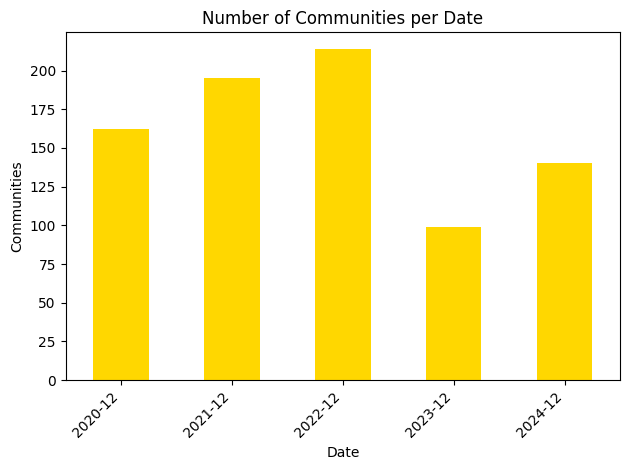

In [10]:
ax = df['number_communities'].plot(kind='bar', color='gold')
ax.set_title('Number of Communities per Date')
ax.set_xlabel('Date')
ax.set_ylabel('Communities')
ax.set_xticklabels(df.index, rotation=45, ha='right')
plt.tight_layout()

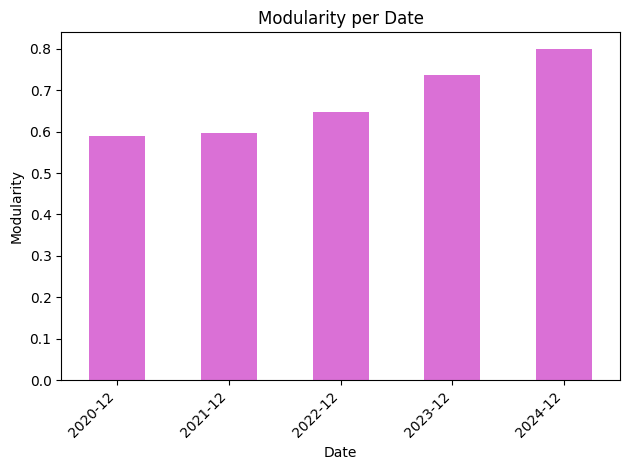

In [12]:
ax = df['modularity'].plot(kind='bar', color='orchid')
ax.set_title('Modularity per Date')
ax.set_xlabel('Date')
ax.set_ylabel('Modularity')
ax.set_xticklabels(df.index, rotation=45, ha='right')
plt.tight_layout()

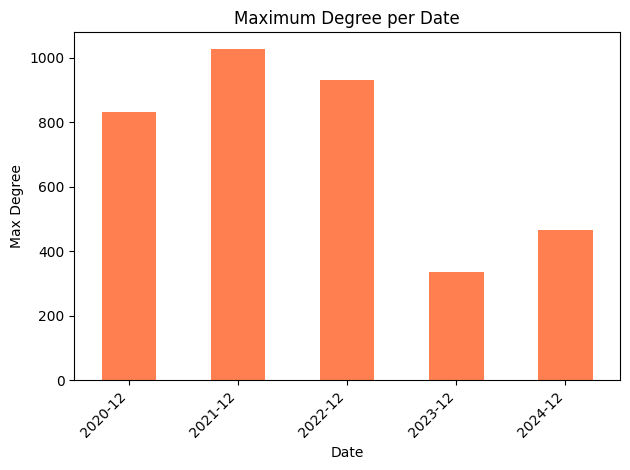

In [14]:
ax = df['max_degree'].plot(kind='bar', color='coral')
ax.set_title('Maximum Degree per Date')
ax.set_xlabel('Date')
ax.set_ylabel('Max Degree')
ax.set_xticklabels(df.index, rotation=45, ha='right')
plt.tight_layout()

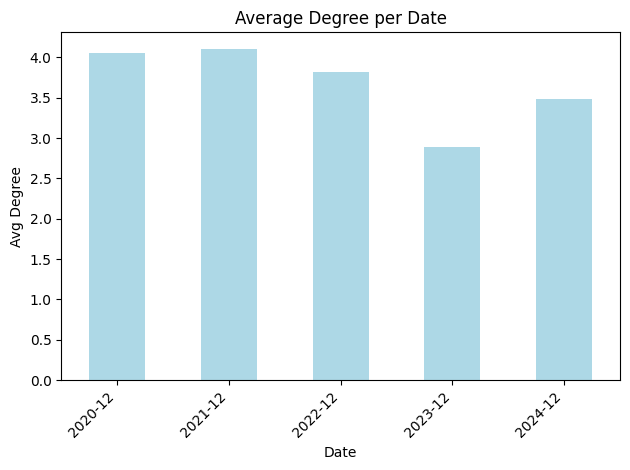

In [13]:
ax = df['avg_degree'].plot(kind='bar', color='lightblue')
ax.set_title('Average Degree per Date')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Degree')
ax.set_xticklabels(df.index, rotation=45, ha='right')
plt.tight_layout()

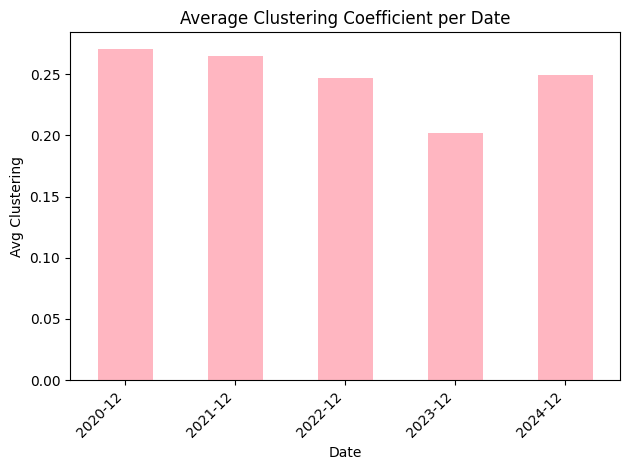

In [15]:
ax = df['avg_clustering'].plot(kind='bar', color='lightpink')
ax.set_title('Average Clustering Coefficient per Date')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Clustering')
ax.set_xticklabels(df.index, rotation=45, ha='right')
plt.tight_layout()

In [6]:
print("Sample nodes with attributes:")
for node, attrs in islice(G.nodes(data=True), 5):
    print(f"\nNode: {node}")
    print(attrs)

Sample nodes with attributes:

Node: t5_3l4jr
{'name': 'gamesEcultura', 'users': 3622, 'interactions': 69621, 'community': 12, '_igraph_index': 0}

Node: t5_4pro8w
{'name': 'MeJulgue', 'users': 8398, 'interactions': 106298, 'community': 12, '_igraph_index': 1}

Node: t5_2ukaa
{'name': 'naughtydog', 'users': 1053, 'interactions': 21545, 'community': 1, '_igraph_index': 2}

Node: t5_2xgtw
{'name': 'TheLastOfUs2', 'users': 2224, 'interactions': 51418, 'community': 1, '_igraph_index': 3}

Node: t5_2thsj
{'name': 'LawFirm', 'users': 648, 'interactions': 7062, 'community': 109, '_igraph_index': 4}


In [7]:
print("Sample edges with attributes:")
for u, v, attrs in islice(G.edges(data=True), 5):
    print(f"\n{u} -> {v}")
    print(attrs)

Sample edges with attributes:

t5_3l4jr -> t5_4pro8w
{'cosine': 0.016137187624558604, 'shared_users': 89, 'jaccard': 0.007459559131673791, '_igraph_index': 0}

t5_3l4jr -> t5_5ppl0w
{'cosine': 0.04039890695487239, 'shared_users': 51, 'jaccard': 0.012715033657442034, '_igraph_index': 1}

t5_3l4jr -> t5_2qh9i
{'cosine': 0.05604407040604752, 'shared_users': 254, 'jaccard': 0.028100453589998894, '_igraph_index': 2}

t5_3l4jr -> t5_3anl0
{'cosine': 0.017068470827718844, 'shared_users': 29, 'jaccard': 0.006605922551252847, '_igraph_index': 3}

t5_3l4jr -> t5_3bbsj
{'cosine': 0.031370131593106955, 'shared_users': 60, 'jaccard': 0.013123359580052493, '_igraph_index': 4}


In [12]:
community_sizes = Counter(
    attrs["community"]
    for _, attrs in G.nodes(data=True)
    if "community" in attrs
)

print(f"Number of communities: {len(community_sizes)}")

Number of communities: 229


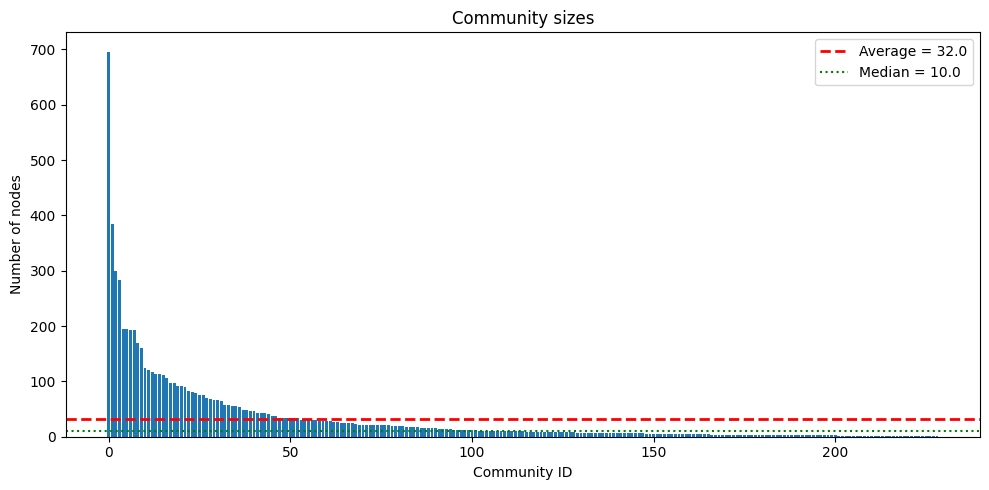

In [58]:
communities = sorted(community_sizes.keys())
sizes = [community_sizes[c] for c in communities]

avg_size = np.mean(sizes)

plt.figure(figsize=(10, 5))
plt.bar(communities, sizes)

plt.axhline(
    y=avg_size,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Average = {avg_size:.1f}"
)

median = np.median(sizes)

plt.axhline(median, color="green", linestyle=":", label=f"Median = {median:.1f}")

plt.xlabel("Community ID")
plt.ylabel("Number of nodes")
plt.title("Community sizes")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
communities = defaultdict(set)

for node, attrs in G.nodes(data=True):
    communities[attrs["community"]].add(node)

Q = modularity(G, communities.values())

print(f"Modularity: {Q:.4f}")

Modularity: 0.7609


In [27]:
degrees = dict(G.degree())

print("Max degree:", max(degrees.values()))
print("Average degree:", sum(degrees.values()) / len(degrees))

Max degree: 999
Average degree: 4.559442470620388


In [28]:
print("Average clustering:", nx.average_clustering(G))

Average clustering: 0.32900877672305856


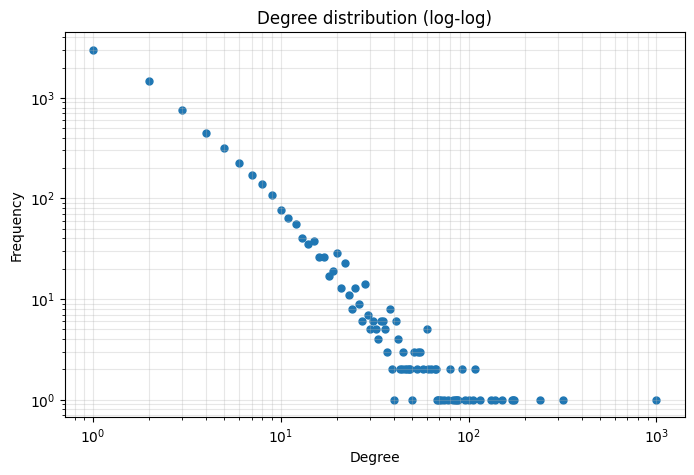

In [42]:
degree_counts = Counter(degrees)

x = np.array(sorted(degree_counts.keys()))
y = np.array([degree_counts[d] for d in x])

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=25)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree distribution (log-log)")
plt.grid(alpha=0.3, which="both")
plt.show()

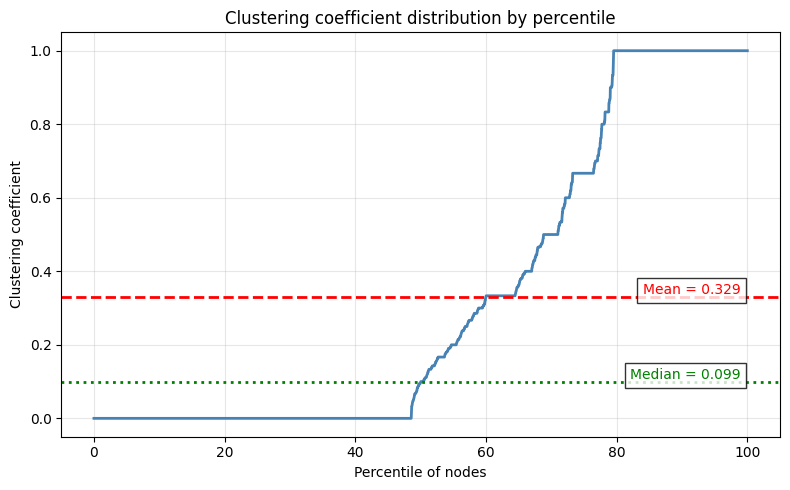

In [46]:
# Compute clustering coefficient for every node
clustering = np.array(list(nx.clustering(G).values()))
clustering.sort()

# Percentiles
percentiles = np.linspace(0, 100, len(clustering))

# Statistics
mean_clustering = clustering.mean()
median_clustering = np.median(clustering)

plt.figure(figsize=(8, 5))

plt.plot(percentiles, clustering, linewidth=2, color="steelblue")

# Reference lines
plt.axhline(mean_clustering, color="red", linestyle="--", linewidth=2)
plt.axhline(median_clustering, color="green", linestyle=":", linewidth=2)

# Labels
plt.text(
    99,
    mean_clustering,
    f"Mean = {mean_clustering:.3f}",
    color="red",
    ha="right",
    va="bottom",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.text(
    99,
    median_clustering,
    f"Median = {median_clustering:.3f}",
    color="green",
    ha="right",
    va="bottom",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.xlabel("Percentile of nodes")
plt.ylabel("Clustering coefficient")
plt.title("Clustering coefficient distribution by percentile")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
degree_centrality = nx.degree_centrality(G)

In [48]:
betweenness = nx.betweenness_centrality(G)

In [49]:
closeness = nx.closeness_centrality(G)

In [53]:
top5 = sorted(
    degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]

for node, score in top5:
    print("\nNode:", node)
    print("Centrality:", score)
    print("Attributes:", G.nodes[node])


Node: t5_2qh1i
Centrality: 0.13653136531365312
Attributes: {'name': 'AskReddit', 'users': 177053, 'interactions': 2861677, 'community': 0, '_igraph_index': 45}

Node: t5_446kys
Centrality: 0.04346043460434604
Attributes: {'name': 'AITAH', 'users': 88260, 'interactions': 1446044, 'community': 0, '_igraph_index': 180}

Node: t5_4uoy2u
Centrality: 0.03293699603662703
Attributes: {'name': 'AmIOverreacting', 'users': 58949, 'interactions': 921030, 'community': 0, '_igraph_index': 146}

Node: t5_2cneq
Centrality: 0.023916905835725023
Attributes: {'name': 'politics', 'users': 32004, 'interactions': 730133, 'community': 0, '_igraph_index': 117}

Node: t5_aqq00d
Centrality: 0.02350690173568402
Attributes: {'name': 'marvelrivals', 'users': 45416, 'interactions': 646967, 'community': 21, '_igraph_index': 26}


In [54]:
top5 = sorted(
    betweenness.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]

for node, score in top5:
    print("\nNode:", node)
    print("Centrality:", score)
    print("Attributes:", G.nodes[node])


Node: t5_2qh1i
Centrality: 0.7537982959605382
Attributes: {'name': 'AskReddit', 'users': 177053, 'interactions': 2861677, 'community': 0, '_igraph_index': 45}

Node: t5_2qq5c
Centrality: 0.05538732313361716
Attributes: {'name': 'gonewild', 'users': 16163, 'interactions': 353532, 'community': 4, '_igraph_index': 486}

Node: t5_10pwqg
Centrality: 0.04917473791594273
Attributes: {'name': 'GOONED', 'users': 44197, 'interactions': 756448, 'community': 17, '_igraph_index': 1217}

Node: t5_2qi58
Centrality: 0.04561825473801624
Attributes: {'name': 'soccer', 'users': 22377, 'interactions': 489188, 'community': 9, '_igraph_index': 142}

Node: t5_446kys
Centrality: 0.03925140989869171
Attributes: {'name': 'AITAH', 'users': 88260, 'interactions': 1446044, 'community': 0, '_igraph_index': 180}


In [56]:
top5 = sorted(
    closeness.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]

for node, score in top5:
    print("\nNode:", node)
    print("Centrality:", score)
    print("Attributes:", G.nodes[node])


Node: t5_2qh1i
Centrality: 0.3919121585431173
Attributes: {'name': 'AskReddit', 'users': 177053, 'interactions': 2861677, 'community': 0, '_igraph_index': 45}

Node: t5_446kys
Centrality: 0.3168629828512039
Attributes: {'name': 'AITAH', 'users': 88260, 'interactions': 1446044, 'community': 0, '_igraph_index': 180}

Node: t5_aqq00d
Centrality: 0.3110969387755102
Attributes: {'name': 'marvelrivals', 'users': 45416, 'interactions': 646967, 'community': 21, '_igraph_index': 26}

Node: t5_4uoy2u
Centrality: 0.30981919803531355
Attributes: {'name': 'AmIOverreacting', 'users': 58949, 'interactions': 921030, 'community': 0, '_igraph_index': 146}

Node: t5_2w844
Centrality: 0.30947849257708415
Attributes: {'name': 'NoStupidQuestions', 'users': 31877, 'interactions': 768598, 'community': 0, '_igraph_index': 498}
